# TinyML Lab 1: Payload Safety Detection Using Gyroscope Data

TinyML (Tiny Machine Learning) means running machine learning models on small, low-power devices. In this experiment a pen is placed on a phone, the phone is tilted until the pen falls, and then the phone is brought back flat. We use the phone's gyroscope recording to find these events, train a small neural network to detect the unsafe moment, convert it to an 8-bit integer (INT8) TensorFlow Lite model, and export it as a C header file for a microcontroller unit (MCU).

## 1. Setup
We import the libraries, fix the random seed so results are more repeatable, and print the Python path and versions to confirm that the notebook is running on the `tf_env` kernel.

In [49]:
import os
import re
import sys
import time
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.signal import butter, filtfilt, find_peaks
from scipy.integrate import cumulative_trapezoid
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore", message=".*tf.lite.Interpreter is deprecated.*")
keras.utils.set_random_seed(42)

print("Python:", sys.executable)
print(f"NumPy {np.__version__} | pandas {pd.__version__} | TensorFlow {tf.__version__}")

Python: /Users/Tanmay/Downloads/tf_env/bin/python
NumPy 2.5.3 | pandas 3.0.6 | TensorFlow 2.21.0


## 2. Load and clean the data
We read the CSV (Comma-Separated Values) file, give the columns short names, remove missing and duplicate rows, and sort by time. We then estimate the sampling rate in hertz (Hz), compute the total rotation speed (magnitude) as $\sqrt{x^2 + y^2 + z^2}$ in radians per second (rad/s), and compare it with the magnitude recorded by the app.

In [50]:
FILE_PATH = Path("/Users/Tanmay/Downloads/Gyroscope (Rotation Rate) 2026-09-22 08-26-40/Raw Data.csv")
if not FILE_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {FILE_PATH}")

raw = pd.read_csv(FILE_PATH)
print("Raw shape:", raw.shape, "| Missing values:", int(raw.isnull().sum().sum()))
display(raw.head())

df = raw.set_axis(["time", "gyro_x", "gyro_y", "gyro_z", "gyro_abs"], axis=1)
df = (df.apply(pd.to_numeric, errors="coerce").dropna().drop_duplicates()
        .sort_values("time").reset_index(drop=True))

dt = np.diff(df["time"])
fs = 1 / dt[dt > 0].mean()
df["gyro_mag"] = np.linalg.norm(df[["gyro_x", "gyro_y", "gyro_z"]], axis=1)
mag_difference = (df["gyro_abs"] - df["gyro_mag"]).abs().max()

print(f"Cleaned shape: {df.shape} | Sampling rate: {fs:.2f} Hz")
print(f"Largest difference from the recorded magnitude: {mag_difference:.4f} rad/s")

Raw shape: (2155, 5) | Missing values: 0


,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
0,0.002250,0.132437,-0.097075,0.118641,0.202581
1,0.012236,0.120041,-0.101400,0.136454,0.208114
2,0.022222,0.118343,-0.074125,0.125597,0.187814
3,0.032208,0.120874,-0.034187,0.093242,0.156440
4,0.042194,0.109652,0.008451,0.056145,0.123480


Cleaned shape: (2155, 6) | Sampling rate: 100.14 Hz
Largest difference from the recorded magnitude: 0.0000 rad/s


## 3. Filter the signal
A Butterworth low-pass filter with a 10 Hz cutoff removes fast noise but keeps the slower tilting motion. `filtfilt` runs the filter forward and backward so the signal is not shifted in time. The top plot shows the raw data and the bottom plot shows the effect of the filter.

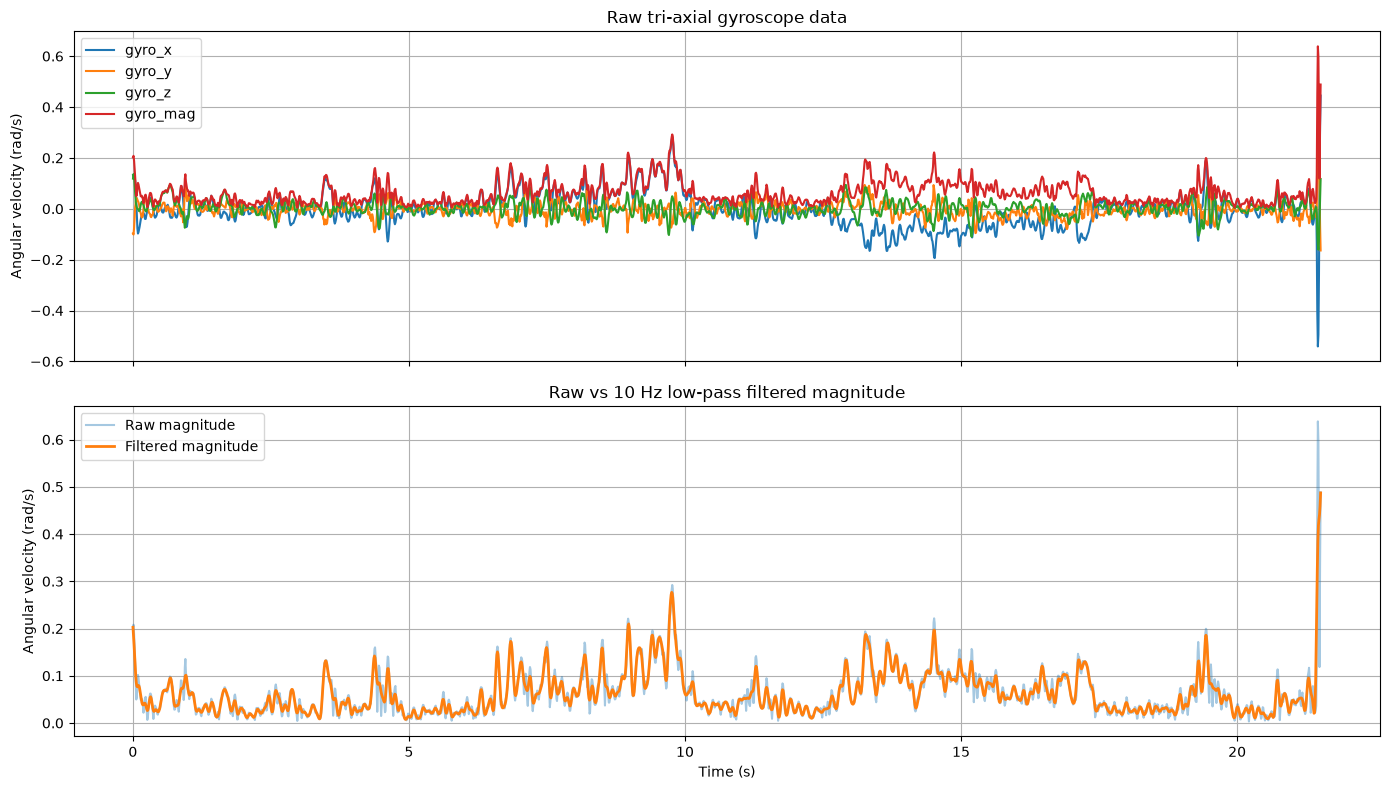

In [51]:
AXES = ["gyro_x", "gyro_y", "gyro_z"]
b, a = butter(3, 10 / (0.5 * fs), btype="low")
for col in AXES + ["gyro_mag"]:
    df[f"{col}_filtered"] = filtfilt(b, a, df[col])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for col in AXES + ["gyro_mag"]:
    ax1.plot(df["time"], df[col], label=col)
ax2.plot(df["time"], df["gyro_mag"], alpha=0.4, label="Raw magnitude")
ax2.plot(df["time"], df["gyro_mag_filtered"], lw=2, label="Filtered magnitude")
ax1.set(title="Raw tri-axial gyroscope data", ylabel="Angular velocity (rad/s)")
ax2.set(title="Raw vs 10 Hz low-pass filtered magnitude", xlabel="Time (s)",
        ylabel="Angular velocity (rad/s)")
for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

## 4. Motion threshold and peaks
The first 3 seconds are a calm baseline. The motion threshold is the baseline mean plus 3 standard deviations (SD). We also find clear peaks in the filtered magnitude that are at least 1 second apart and stand out by at least 0.04 rad/s (prominence).

Baseline mean: 0.0447 rad/s | Baseline SD: 0.0261 rad/s | Motion threshold: 0.1231 rad/s


,time,magnitude,prominence
0,0.9609,0.1012,0.0774
1,2.8783,0.0712,0.0597
2,4.3762,0.1419,0.1332
3,6.8427,0.1728,0.1368
4,8.5004,0.1589,0.1053
5,9.7587,0.2766,0.2675
6,11.2865,0.1202,0.1045
7,13.2737,0.1875,0.1560
8,14.5119,0.1968,0.1868
9,15.6304,0.1005,0.0426


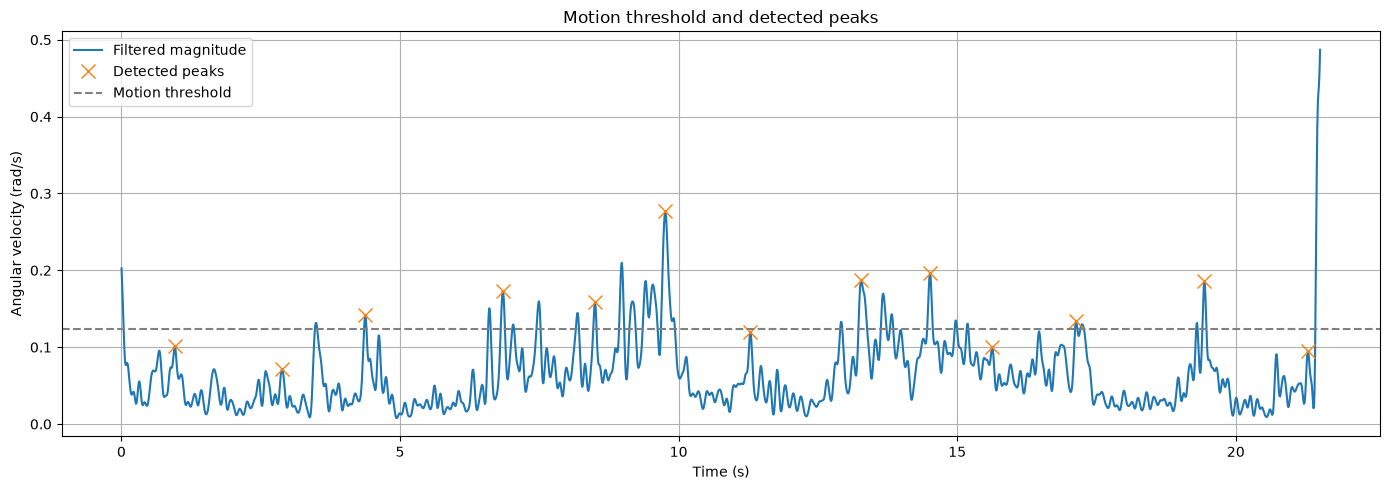

In [52]:
BASELINE_DURATION = 3.0
baseline = df.loc[df["time"] <= BASELINE_DURATION, "gyro_mag_filtered"]
motion_threshold = baseline.mean() + 3 * baseline.std()
print(f"Baseline mean: {baseline.mean():.4f} rad/s | Baseline SD: {baseline.std():.4f} rad/s"
      f" | Motion threshold: {motion_threshold:.4f} rad/s")

peaks, props = find_peaks(df["gyro_mag_filtered"], prominence=0.04, distance=int(fs))
peak_table = pd.DataFrame({"time": df["time"].values[peaks],
                           "magnitude": df["gyro_mag_filtered"].values[peaks],
                           "prominence": props["prominences"]})
display(peak_table.round(4))

plt.figure(figsize=(14, 5))
plt.plot(df["time"], df["gyro_mag_filtered"], label="Filtered magnitude")
plt.plot(peak_table["time"], peak_table["magnitude"], "x", ms=10, label="Detected peaks")
plt.axhline(motion_threshold, ls="--", color="gray", label="Motion threshold")
plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.title("Motion threshold and detected peaks")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Tilt angle and key events
The gyroscope measures rotation speed, so integrating it over time gives the tilt angle. We remove the small sensor offset measured during the baseline, integrate the axis that rotates the most, and use the angle to estimate the key events:

- **Tilting stopped:** the angle first reaches 95% of its maximum.
- **Pen fell:** the strongest short jolt (the fast vibration removed by the filter) while the phone is held at its highest tilt.
- **Back flat:** the angle drops back to within 5% of its lowest level after the return.

These times are approximate. If you noted the real times during the experiment, type them in the marked line.

Main rotation axis: x


,Time (s),Tilt angle (deg)
Tilting started,5.49,0.89
Tilting stopped,9.96,19.40
Pen fell,10.10,19.85
Return started,12.36,19.37
Back flat,17.18,0.83


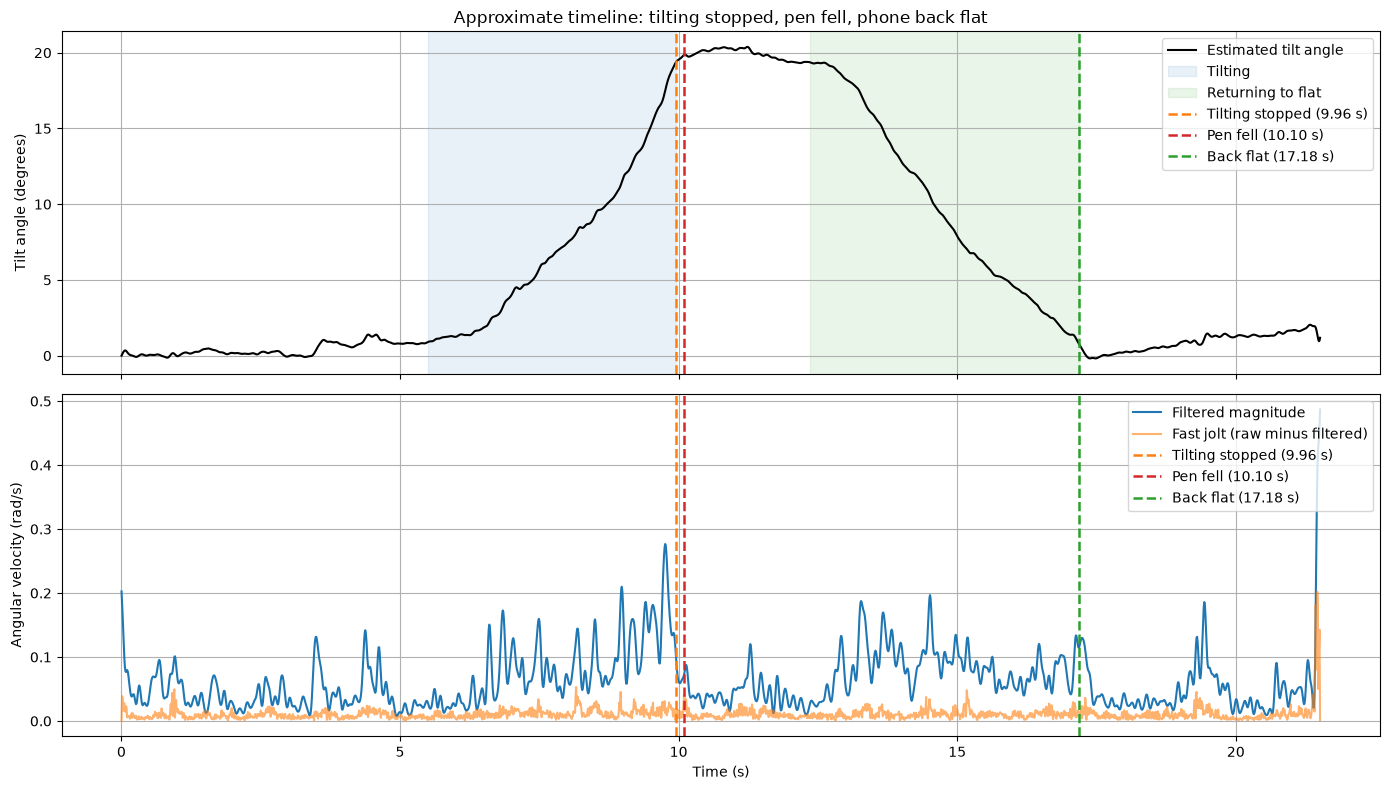

In [53]:
t = df["time"].values
filtered = df[[f"{c}_filtered" for c in AXES]]
angles = np.degrees(cumulative_trapezoid(
    filtered - filtered[t <= BASELINE_DURATION].mean(), t, axis=0, initial=0))
tilt_axis = int(np.abs(angles).max(axis=0).argmax())
theta = angles[:, tilt_axis] * np.sign(angles[np.abs(angles[:, tilt_axis]).argmax(), tilt_axis])
df["tilt_angle"] = theta
jolt = np.linalg.norm(df[AXES].values - filtered.values, axis=1)

peak = theta.max()
high = np.flatnonzero(theta >= 0.95 * peak)
stop_i, return_i = high[0], high[-1]
before, after = theta[:stop_i + 1], theta[return_i:]
start_i = np.flatnonzero(before <= before.min() + 0.05 * (peak - before.min()))[-1]
flat_i = return_i + np.flatnonzero(after <= after.min() + 0.05 * (peak - after.min()))[0]
fall_i = stop_i + jolt[stop_i:return_i + 1].argmax()

TILT_START, TILT_STOP, FALL_TIME, RETURN_START, RETURN_TIME = t[[start_i, stop_i, fall_i, return_i, flat_i]]
# Optional manual override, for example: FALL_TIME = 9.5

event_times = {"Tilting started": TILT_START, "Tilting stopped": TILT_STOP, "Pen fell": FALL_TIME,
               "Return started": RETURN_START, "Back flat": RETURN_TIME}
events = pd.DataFrame({"Time (s)": event_times,
                       "Tilt angle (deg)": {k: np.interp(v, t, theta) for k, v in event_times.items()}})
print("Main rotation axis:", "xyz"[tilt_axis])
display(events.round(2))


def mark_events(ax):
    for name, color in [("Tilting stopped", "tab:orange"), ("Pen fell", "tab:red"), ("Back flat", "tab:green")]:
        ax.axvline(event_times[name], color=color, ls="--", lw=1.8, label=f"{name} ({event_times[name]:.2f} s)")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(t, theta, color="black", label="Estimated tilt angle")
ax1.axvspan(TILT_START, TILT_STOP, color="tab:blue", alpha=0.1, label="Tilting")
ax1.axvspan(RETURN_START, RETURN_TIME, color="tab:green", alpha=0.1, label="Returning to flat")
ax2.plot(t, df["gyro_mag_filtered"], label="Filtered magnitude")
ax2.plot(t, jolt, alpha=0.6, label="Fast jolt (raw minus filtered)")
ax1.set(title="Approximate timeline: tilting stopped, pen fell, phone back flat", ylabel="Tilt angle (degrees)")
ax2.set(xlabel="Time (s)", ylabel="Angular velocity (rad/s)")
for ax in (ax1, ax2):
    mark_events(ax)
    ax.legend(loc="upper right")
    ax.grid(True)
plt.tight_layout()
plt.show()

## 6. Split the recording into phases
Each sample gets a phase based on the event times: calm baseline, tilt or movement, fall, return, and final stable. For each phase we compute the mean, SD, peak, and root mean square (RMS) of the filtered magnitude. RMS shows the overall strength of the motion.

In [54]:
def calculate_rms(x):
    return np.sqrt(np.mean(np.square(x)))


df["phase"] = np.select(
    [t < BASELINE_DURATION, t < FALL_TIME - 1.0, t < FALL_TIME + 0.1, t < RETURN_TIME],
    ["Phase 1 - Calm Baseline", "Phase 2 - Tilt / Movement", "Phase 3 - Fall / Unstable", "Phase 4 - Return"],
    default="Phase 5 - Final Stable")

phase_stats = (df.groupby("phase")["gyro_mag_filtered"]
                 .agg(Samples="size", Mean="mean", Std="std", Peak="max", RMS=calculate_rms)
                 .reset_index())
display(phase_stats)

,phase,Samples,Mean,Std,Peak,RMS
0,Phase 1 - Calm Baseline,301,0.044708,0.026143,0.202522,0.051769
1,Phase 2 - Tilt / Movement,610,0.058408,0.039021,0.209789,0.070225
2,Phase 3 - Fall / Unstable,111,0.132705,0.054892,0.276633,0.143515
3,Phase 4 - Return,698,0.070788,0.036962,0.196843,0.079845
4,Phase 5 - Final Stable,435,0.052091,0.057666,0.487009,0.077661


## 7. Coefficient of friction
When the pen starts to slide, the coefficient of static friction is $\mu_s = \tan(\theta_c)$, where $\theta_c$ is the critical angle. We use the tilt angle at the moment the pen fell as $\theta_c$. The rotational method $\mu_s = \omega_c^2 r / g$ uses placeholder values for the radius $r$ and the critical angular velocity $\omega_c$, so replace them with your measurements.

In [55]:
critical_angle_deg = float(np.interp(FALL_TIME, t, theta))
mu_s = np.tan(np.radians(critical_angle_deg))

radius_m = 0.10        # CHANGE to your measured radius
critical_omega = 0.50  # CHANGE to your measured critical angular velocity
mu_s_rotation = critical_omega**2 * radius_m / 9.81

print(f"Critical angle: {critical_angle_deg:.2f} degrees")
print(f"Coefficient of static friction (tilt method): {mu_s:.4f}")
print(f"Coefficient of static friction (rotation method): {mu_s_rotation:.4f}")

Critical angle: 19.85 degrees
Coefficient of static friction (tilt method): 0.3610
Coefficient of static friction (rotation method): 0.0025


## 8. Windows, features, and labels
We cut the recording into 1-second windows that move forward by 0.5 seconds. For each window we compute 5 features (mean, SD, minimum, maximum, RMS) for 4 signals (x, y, z, magnitude), which gives 20 features. A window is UNSAFE (1) if it overlaps the period from 0.5 seconds before to 0.2 seconds after the pen fall. All other windows are SAFE (0).

In [56]:
window_size, step_size = int(round(1.0 * fs)), int(round(0.5 * fs))
UNSAFE_START, UNSAFE_END = FALL_TIME - 0.5, FALL_TIME + 0.2
SIGNALS = {"x": "gyro_x_filtered", "y": "gyro_y_filtered", "z": "gyro_z_filtered", "mag": "gyro_mag_filtered"}


def extract_features(window):
    features = {}
    for name, col in SIGNALS.items():
        v = window[col].values
        features.update({f"{name}_mean": v.mean(), f"{name}_std": v.std(), f"{name}_min": v.min(),
                         f"{name}_max": v.max(), f"{name}_rms": calculate_rms(v)})
    return features


rows = []
for s in range(0, len(df) - window_size + 1, step_size):
    w = df.iloc[s:s + window_size]
    rows.append({**extract_features(w), "start_time": w["time"].iloc[0], "end_time": w["time"].iloc[-1]})

window_df = pd.DataFrame(rows)
window_df["label"] = ((window_df["end_time"] >= UNSAFE_START) &
                      (window_df["start_time"] <= UNSAFE_END)).astype(int)
feature_columns = [c for c in window_df.columns if c not in ("start_time", "end_time", "label")]

print(f"Windows: {len(window_df)} | Samples per window: {window_size} | Features: {len(feature_columns)}")
print(window_df["label"].value_counts().rename({0: "SAFE", 1: "UNSAFE"}).to_string())

Windows: 42 | Samples per window: 100 | Features: 20
label
SAFE      39
UNSAFE     3


## 9. Train the neural network
We keep 20% of the windows for testing (`stratify` keeps UNSAFE windows in both sets) and standardize the features to mean 0 and SD 1 using the training data only. The network has two hidden layers of 16 and 8 neurons with the Rectified Linear Unit (ReLU) activation and a sigmoid output that gives the probability of UNSAFE. It trains for 50 epochs, with 20% of the training data used for validation.

Training windows: 33 | Test windows: 9


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

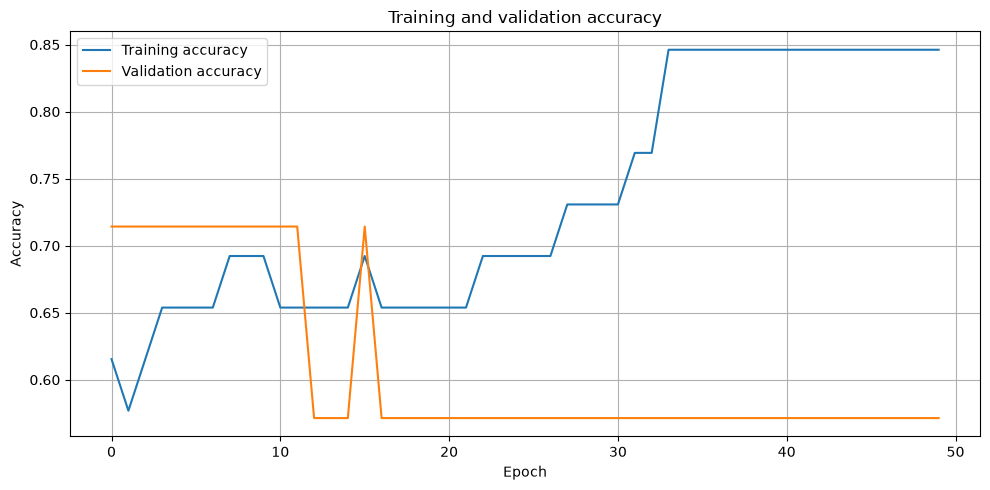

In [57]:
X, y = window_df[feature_columns].values, window_df["label"].values
idx_train, idx_test = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler().fit(X[idx_train])
X_train_scaled, X_test_scaled = scaler.transform(X[idx_train]), scaler.transform(X[idx_test])
y_train, y_test = y[idx_train], y[idx_test]
print(f"Training windows: {len(y_train)} | Test windows: {len(y_test)}")

model = keras.Sequential([
    layers.Input(shape=(X.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

class_weight = {0: 1.0, 1: float((y_train == 0).sum() / max((y_train == 1).sum(), 1))}
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=0, class_weight=class_weight)

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Evaluate the model
A probability of 0.5 or more is labeled UNSAFE. We report accuracy, precision, recall, and F1 score (the balance of precision and recall), and plot the confusion matrix. For safety, recall on UNSAFE matters most, because a missed fall is worse than a false alarm.

Accuracy: 0.7778 | Precision: 0.0000 | Recall: 0.0000 | F1 score: 0.0000

              precision    recall  f1-score   support

        SAFE       0.88      0.88      0.88         8
      UNSAFE       0.00      0.00      0.00         1

    accuracy                           0.78         9
   macro avg       0.44      0.44      0.44         9
weighted avg       0.78      0.78      0.78         9



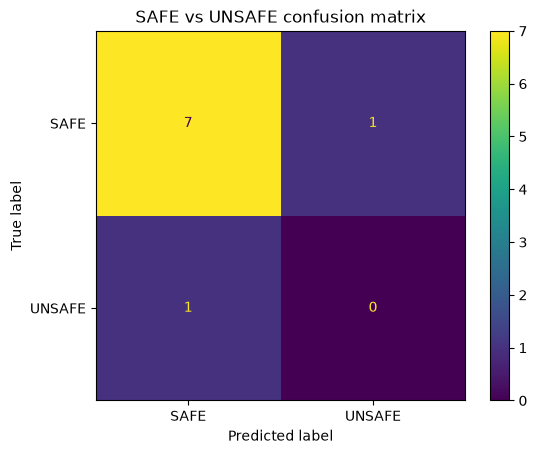

In [58]:
LABELS = np.array(["SAFE", "UNSAFE"])
probabilities = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1 score: {f1:.4f}\n")
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=LABELS, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0, 1], display_labels=LABELS)
plt.title("SAFE vs UNSAFE confusion matrix")
plt.show()

## 11. Convert to TensorFlow Lite
We save the Keras model and convert it to TensorFlow Lite (TFLite) twice: once in 32-bit floating point (Float32) and once in INT8. The INT8 conversion uses training windows as a representative dataset to learn the range of values in each layer. We then compare the file sizes.

In [59]:
os.makedirs("models", exist_ok=True)
model.save("models/payload_safety_model.keras")
PATHS = {"float32": "models/payload_safety_float32.tflite", "int8": "models/payload_safety_int8.tflite"}

for name, path in PATHS.items():
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    if name == "int8":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = lambda: ([x[None].astype(np.float32)] for x in X_train_scaled[:200])
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = converter.inference_output_type = tf.int8
    Path(path).write_bytes(converter.convert())

float32_kb, int8_kb = (os.path.getsize(p) / 1024 for p in PATHS.values())
reduction = (1 - int8_kb / float32_kb) * 100
print(f"\nFloat32 model: {float32_kb:.2f} KB | INT8 model: {int8_kb:.2f} KB | Size reduction: {reduction:.2f}%")

INFO:tensorflow:Assets written to: /var/folders/_v/pk2x5_cn235c84mks_bl5r000000gp/T/tmpyjq94kak/assets


INFO:tensorflow:Assets written to: /var/folders/_v/pk2x5_cn235c84mks_bl5r000000gp/T/tmpyjq94kak/assets


Saved artifact at '/var/folders/_v/pk2x5_cn235c84mks_bl5r000000gp/T/tmpyjq94kak'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  4943880144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943876304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943888016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943875728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943872080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943877264: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: /var/folders/_v/pk2x5_cn235c84mks_bl5r000000gp/T/tmpxstnx6m3/assets


INFO:tensorflow:Assets written to: /var/folders/_v/pk2x5_cn235c84mks_bl5r000000gp/T/tmpxstnx6m3/assets


Saved artifact at '/var/folders/_v/pk2x5_cn235c84mks_bl5r000000gp/T/tmpxstnx6m3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  4943880144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943876304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943888016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943875728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943872080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4943877264: TensorSpec(shape=(), dtype=tf.resource, name=None)

Float32 model: 4.04 KB | INT8 model: 3.61 KB | Size reduction: 10.64%


/Users/Tanmay/Downloads/tf_env/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 12. Inference on the test windows
We run the Float32 and INT8 TFLite models on the test windows. INT8 inputs are made with $q = \text{round}(x / s) + z$ and outputs are converted back with $x = (q - z) \times s$, where $s$ is the scale and $z$ is the zero point. The table compares all three models with the true labels.

In [60]:
def make_interpreter(**kwargs):
    interpreter = tf.lite.Interpreter(**kwargs)
    interpreter.allocate_tensors()
    return interpreter


def tflite_predict(interpreter, X_scaled):
    inp, out = interpreter.get_input_details()[0], interpreter.get_output_details()[0]
    results = []
    for x in np.asarray(X_scaled, dtype=np.float32)[:, None, :]:
        if inp["dtype"] == np.int8:
            scale, zero = inp["quantization"]
            x = np.clip(np.round(x / scale + zero), -128, 127).astype(np.int8)
        interpreter.set_tensor(inp["index"], x)
        interpreter.invoke()
        y_out = interpreter.get_tensor(out["index"]).astype(np.float32)
        if out["dtype"] == np.int8:
            scale, zero = out["quantization"]
            y_out = (y_out - zero) * scale
        results.append(y_out.item())
    return np.array(results)


int8_interpreter = make_interpreter(model_path=PATHS["int8"])
input_scale, input_zero_point = int8_interpreter.get_input_details()[0]["quantization"]
output_scale, output_zero_point = int8_interpreter.get_output_details()[0]["quantization"]
print(f"Input scale: {input_scale:.6f}, zero point: {input_zero_point} | "
      f"Output scale: {output_scale:.6f}, zero point: {output_zero_point}")

float32_probs = tflite_predict(make_interpreter(model_path=PATHS["float32"]), X_test_scaled)
int8_probs = tflite_predict(int8_interpreter, X_test_scaled)
tflite_accuracy = accuracy_score(y_test, (int8_probs >= 0.5).astype(int))

display(window_df.loc[idx_test, ["start_time", "end_time"]]
        .assign(true_label=LABELS[y_test], keras_prob=probabilities, float32_prob=float32_probs,
                int8_prob=int8_probs, int8_prediction=LABELS[(int8_probs >= 0.5).astype(int)])
        .sort_values("start_time").round(4))

print(f"Accuracy: Keras {accuracy:.4f} | INT8 TFLite {tflite_accuracy:.4f}")
print(f"Largest probability difference from Keras: Float32 {np.abs(probabilities - float32_probs).max():.6f}"
      f" | INT8 {np.abs(probabilities - int8_probs).max():.6f}")

Input scale: 0.022919, zero point: -19 | Output scale: 0.003906, zero point: -128


,start_time,end_time,true_label,keras_prob,float32_prob,int8_prob,int8_prediction
7,3.4974,4.4860,SAFE,0.3661,0.3661,0.3633,SAFE
10,4.9953,5.9839,SAFE,0.1375,0.1375,0.1367,SAFE
14,6.9925,7.9812,SAFE,0.3516,0.3516,0.3516,SAFE
20,9.9883,10.9770,UNSAFE,0.2245,0.2245,0.2227,SAFE
21,10.4876,11.4762,SAFE,0.2268,0.2268,0.2266,SAFE
23,11.4862,12.4748,SAFE,0.1378,0.1378,0.1367,SAFE
25,12.4848,13.4734,SAFE,0.3076,0.3076,0.3125,SAFE
31,15.4806,16.4692,SAFE,0.4679,0.4679,0.4648,SAFE
41,20.4735,21.4621,SAFE,0.7368,0.7368,0.7500,UNSAFE


Accuracy: Keras 0.7778 | INT8 TFLite 0.7778
Largest probability difference from Keras: Float32 0.000000 | INT8 0.013235


## 13. Inference on the full recording
We run the INT8 model on every window and plot the UNSAFE probability over time with the key events marked. Most of these windows were also used for training, so this plot shows how the model behaves over time, not its accuracy on new data.

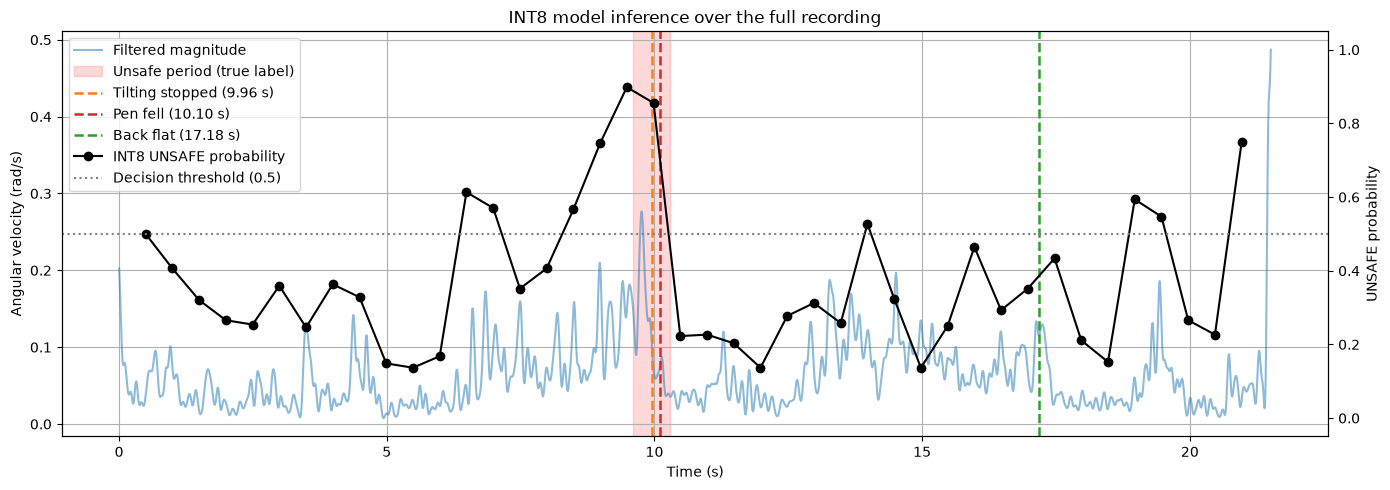

Flagged UNSAFE: 11 of 42 | False alarms: 9 | Missed UNSAFE: 1


In [61]:
timeline_df = window_df[["start_time", "end_time", "label"]].assign(
    int8_unsafe_prob=tflite_predict(int8_interpreter, scaler.transform(X)))
timeline_df["int8_prediction"] = (timeline_df["int8_unsafe_prob"] >= 0.5).astype(int)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(t, df["gyro_mag_filtered"], alpha=0.5, label="Filtered magnitude")
ax1.axvspan(UNSAFE_START, UNSAFE_END, color="red", alpha=0.15, label="Unsafe period (true label)")
mark_events(ax1)
ax1.set(xlabel="Time (s)", ylabel="Angular velocity (rad/s)", title="INT8 model inference over the full recording")
ax2 = ax1.twinx()
ax2.plot((timeline_df["start_time"] + timeline_df["end_time"]) / 2, timeline_df["int8_unsafe_prob"],
         "o-", color="black", label="INT8 UNSAFE probability")
ax2.axhline(0.5, ls=":", color="gray", label="Decision threshold (0.5)")
ax2.set(ylim=(-0.05, 1.05), ylabel="UNSAFE probability")
handles = [h for ax in (ax1, ax2) for h in ax.get_legend_handles_labels()[0]]
ax1.legend(handles=handles, loc="upper left")
ax1.grid(True)
plt.tight_layout()
plt.show()

pred, true = timeline_df["int8_prediction"], timeline_df["label"]
print(f"Flagged UNSAFE: {pred.sum()} of {len(pred)} | False alarms: {((pred == 1) & (true == 0)).sum()}"
      f" | Missed UNSAFE: {((pred == 0) & (true == 1)).sum()}")

## 14. Device-style inference on single windows
This repeats what a microcontroller would do for one window: extract features, standardize them, convert to INT8, run the model, and convert the output back. We test a calm window and a window centered on the pen fall, and measure the average inference time on this computer.

In [62]:
def classify_window(window):
    features = extract_features(window)
    prob = tflite_predict(int8_interpreter, scaler.transform([[features[c] for c in feature_columns]]))[0]
    return prob, LABELS[int(prob >= 0.5)]


fall_start = int(np.clip(np.searchsorted(t, FALL_TIME - 0.5), 0, len(df) - window_size))
for name, window in [("Calm window", df.iloc[:window_size]),
                     ("Pen fall window", df.iloc[fall_start:fall_start + window_size])]:
    prob, label = classify_window(window)
    print(f"{name} ({window['time'].iloc[0]:.2f} s to {window['time'].iloc[-1]:.2f} s): "
          f"{label} (probability {prob:.3f})")

start = time.perf_counter()
for _ in range(1000):
    int8_interpreter.invoke()
avg_latency_us = (time.perf_counter() - start) * 1000
print(f"\nAverage INT8 inference time on this computer: {avg_latency_us:.1f} microseconds")

Calm window (0.00 s to 0.99 s): UNSAFE (probability 0.500)
Pen fall window (9.60 s to 10.59 s): UNSAFE (probability 0.836)

Average INT8 inference time on this computer: 1.7 microseconds


## 15. Export as a C header file
We write the INT8 model to `models/model.h` as a byte array, together with the feature order, standardization values, and quantization parameters the device needs to prepare its input. We then read the bytes back, check that they match the `.tflite` file, and run one prediction from them.

In [63]:
def c_list(values, fmt, per_line):
    items = [fmt(v) for v in values]
    return ",\n".join("    " + ", ".join(items[i:i + per_line]) for i in range(0, len(items), per_line))


def c_float(v):
    return f"{float(v):.8e}f"


model_bytes = Path(PATHS["int8"]).read_bytes()
feature_comment = "\n".join("//   " + ", ".join(feature_columns[i:i + 5]) for i in range(0, len(feature_columns), 5))
header = f"""#ifndef PAYLOAD_SAFETY_MODEL_H
#define PAYLOAD_SAFETY_MODEL_H

// INT8 TensorFlow Lite model: SAFE / UNSAFE payload classifier ({len(model_bytes)} bytes)
#define PAYLOAD_NUM_FEATURES {len(feature_columns)}
#define PAYLOAD_WINDOW_SIZE {window_size}
#define PAYLOAD_STEP_SIZE {step_size}
#define PAYLOAD_SAMPLING_RATE_HZ {c_float(fs)}
#define PAYLOAD_FILTER_CUTOFF_HZ {c_float(10)}
#define PAYLOAD_UNSAFE_THRESHOLD {c_float(0.5)}

// Feature order:
{feature_comment}

// Standardization: scaled = (feature - mean) / scale
const float payload_feature_mean[PAYLOAD_NUM_FEATURES] = {{
{c_list(scaler.mean_, c_float, 4)}
}};
const float payload_feature_scale[PAYLOAD_NUM_FEATURES] = {{
{c_list(scaler.scale_, c_float, 4)}
}};

// Quantization: int8 = round(real / scale) + zero_point
const float payload_input_scale = {c_float(input_scale)};
const int payload_input_zero_point = {int(input_zero_point)};
const float payload_output_scale = {c_float(output_scale)};
const int payload_output_zero_point = {int(output_zero_point)};

// Model data, aligned to 16 bytes for TensorFlow Lite for Microcontrollers
const unsigned char payload_safety_model[] __attribute__((aligned(16))) = {{
{c_list(model_bytes, lambda v: f"0x{v:02x}", 12)}
}};
const unsigned int payload_safety_model_len = {len(model_bytes)};

#endif // PAYLOAD_SAFETY_MODEL_H
"""
Path("models/model.h").write_text(header)

header_bytes = bytes(int(h, 16) for h in
                     re.findall(r"0x([0-9a-f]{2})", Path("models/model.h").read_text().split("payload_safety_model[]")[1]))
header_prob = tflite_predict(make_interpreter(model_content=header_bytes), X_test_scaled[:1])[0]

print("Header file:", os.path.abspath("models/model.h"), f"({os.path.getsize('models/model.h') / 1024:.2f} KB)")
print("Header bytes match the .tflite file:", header_bytes == model_bytes)
print(f"First test window probability: from header {header_prob:.4f} | from .tflite {int8_probs[0]:.4f}")

Header file: /Users/Tanmay/Downloads/models/model.h (24.77 KB)
Header bytes match the .tflite file: True
First test window probability: from header 0.2266 | from .tflite 0.2266


## 16. Results summary and saved files
We collect the main results in one table and save the processed data, window features, phase statistics, events, and timeline predictions as CSV files in the `results` folder.

In [64]:
results_df = pd.Series({
    "Sampling rate (Hz)": fs, "Raw samples": len(df), "Windows": len(window_df),
    "Features": len(feature_columns), "Pen fall time (s)": FALL_TIME,
    "Critical angle (deg)": critical_angle_deg, "Static friction coefficient": mu_s,
    "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 score": f1,
    "INT8 TFLite accuracy": tflite_accuracy, "Float32 TFLite size (KB)": float32_kb,
    "INT8 TFLite size (KB)": int8_kb, "Size reduction (%)": reduction,
}, name="Value").round(4).to_frame()
display(results_df)

os.makedirs("results", exist_ok=True)
for name, table in {"processed_gyro_data": df, "window_features": window_df, "phase_statistics": phase_stats,
                    "events": events, "timeline_inference": timeline_df}.items():
    table.to_csv(f"results/{name}.csv", index=(name == "events"))
print("Saved CSV files to:", os.path.abspath("results"))

,Value
Sampling rate (Hz),100.1406
Raw samples,2155.0000
Windows,42.0000
Features,20.0000
Pen fall time (s),10.0982
Critical angle (deg),19.8517
Static friction coefficient,0.3610
Accuracy,0.7778
Precision,0.0000
Recall,0.0000


Saved CSV files to: /Users/Tanmay/Downloads/results


## Inferences

1. The computed magnitude closely matches the Absolute column recorded by the app, which confirms the magnitude calculation.
2. The 10 Hz low-pass filter removed small, fast fluctuations such as sensor noise and hand tremor, while keeping the tilting and returning motions, which are much slower than 10 Hz.
3. The calm baseline is not exactly zero. This small level is the noise floor of the sensor, and the threshold of mean plus 3 SD separates real motion from this noise.
4. The tilt angle graph shows the stages of the experiment: the angle rises while the phone is tilted, stays nearly constant while it is held, and drops back when the phone is returned to the table. The angle does not return exactly to zero, because small sensor errors add up during integration (drift) and the phone is not placed back in exactly the same position.
5. The gyroscope measures the rotation of the phone, not the pen. The pen fall shows up only as a small, fast jolt while the phone is held still, so the pen fall time is an estimate. The tilt angle at that moment gives the critical angle and the coefficient of static friction.
6. Phases that contain rotation (tilting and returning) have a higher RMS than the calm baseline, so RMS is a useful feature for telling motion apart from rest.
7. Only the few windows that overlap the 0.7-second unsafe period are UNSAFE, so the classes are highly imbalanced. A model that always predicts SAFE would still get high accuracy, so recall on the UNSAFE class is a better measure than accuracy.
8. The test set contains only about one UNSAFE window, so the evaluation scores can change a lot with a different split. More recordings with several pen falls are needed for a reliable estimate.
9. INT8 quantization made the model file only slightly smaller. The network has just 481 parameters, so most of the file is model structure and quantization settings rather than weights. In larger models the reduction gets close to 75%, because each weight goes from 4 bytes to 1 byte.
10. For most windows the INT8 probabilities stay close to the Keras and Float32 probabilities, so quantization has little effect on this small model. Larger differences can appear for windows with values far outside the training range, such as a sudden tap on the phone, because INT8 inputs are limited to the range -128 to 127.
11. The exported header is only a few kilobytes and also stores the scaling and quantization values, so the microcontroller can prepare its input the same way as during training. The TensorFlow Lite for Microcontrollers runtime needs extra memory on top of this, and the real inference time has to be measured on the board.